<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/IDSNlogo.png" width="300" alt="cognitiveclass.ai logo">
</center>

# Hands-on Lab: Introduction to API

Estimated time needed: **15** minutes

## Objectives

After completing this lab you will be able to:

*   Create and use APIs in Python


### Introduction

An API lets two pieces of software talk to each other. Just like a function, you don't have to know how the API works, only its inputs and outputs.  An essential type of API is a REST API that allows you to access resources via the internet. In this lab, we will review the Pandas Library in the context of an API, we will also review a basic REST API.


In [1]:
!pip install pycoingecko

In [2]:
from pycoingecko import CoinGeckoAPI
cg = CoinGeckoAPI()

bitcoin_data = cg.get_coin_market_chart_by_id(id = 'bitcoin', vs_currency = 'usd', days = 30)

In [3]:
bitcoin_data

{'prices': [[1764756386703, 93187.76365353932],
  [1764759735401, 92967.95172916472],
  [1764763253482, 93014.56287493998],
  [1764766912008, 92955.9934046737],
  [1764770463337, 93155.5710477267],
  [1764774162538, 92689.18467540754],
  [1764777729138, 92462.71285159403],
  [1764781358528, 92358.91089703525],
  [1764784914395, 92991.34046933519],
  [1764788573801, 92701.01925701783],
  [1764792068543, 93042.76426891205],
  [1764795708440, 92956.21718894965],
  [1764799379991, 93748.59078386276],
  [1764802902091, 93717.47149577878],
  [1764806533682, 93428.59451478458],
  [1764810164145, 93035.40920589627],
  [1764813670218, 93194.86563225763],
  [1764817305381, 93855.83582607246],
  [1764820904054, 93567.32981233204],
  [1764824493072, 93361.27533623583],
  [1764828374677, 92899.65881208924],
  [1764831708719, 93124.7224503544],
  [1764835343988, 93344.22464629909],
  [1764838894711, 93162.29916189116],
  [1764842492986, 93576.35582972465],
  [1764846128691, 93249.89554012878],
  [17

In [4]:
import pandas as pd
data = pd.DataFrame(bitcoin_data['prices'], columns=['TimeStamp','Price'])

In [5]:
data

,TimeStamp,Price
0,1764756386703,93187.763654
1,1764759735401,92967.951729
2,1764763253482,93014.562875
3,1764766912008,92955.993405
4,1764770463337,93155.571048
...,...,...
716,1767333789891,88637.903361
717,1767337319219,88861.207521
718,1767340907301,88765.507385
719,1767344429019,88990.471130


In [6]:
data['Date'] = pd.to_datetime(data['TimeStamp'], unit='ms')

In [7]:
data

,TimeStamp,Price,Date
0,1764756386703,93187.763654,2025-12-03 10:06:26.703
1,1764759735401,92967.951729,2025-12-03 11:02:15.401
2,1764763253482,93014.562875,2025-12-03 12:00:53.482
3,1764766912008,92955.993405,2025-12-03 13:01:52.008
4,1764770463337,93155.571048,2025-12-03 14:01:03.337
...,...,...,...
716,1767333789891,88637.903361,2026-01-02 06:03:09.891
717,1767337319219,88861.207521,2026-01-02 07:01:59.219
718,1767340907301,88765.507385,2026-01-02 08:01:47.301
719,1767344429019,88990.471130,2026-01-02 09:00:29.019


In [9]:
candlestick_data = data.groupby(data.Date.dt.date).agg({'Price': ['min', 'max', 'first','last']})

In [12]:
candlestick_data

Price                                          
                     min           max         first          last
Date                                                              
2025-12-03  92358.910897  93748.590784  93187.763654  93717.471496
2025-12-04  92053.418455  93855.835826  93428.594515  92349.580959
2025-12-05  88838.812570  92527.831593  92140.704198  89246.762554
2025-12-06  89301.791831  90081.811173  89307.091545  89301.791831
2025-12-07  88202.394145  91432.388723  89244.762081  89669.562808
2025-12-08  89841.061117  92130.301406  90398.448757  90858.050621
2025-12-09  89908.326460  94267.183294  90626.037343  92790.204490
2025-12-10  91801.718063  92991.948021  92686.104020  92541.975263
2025-12-11  89463.232345  93042.438026  92005.137150  92243.539450
2025-12-12  89947.356218  92584.466523  92494.176916  90323.071796
2025-12-13  90056.960294  90601.319125  90307.260286  90170.685696
2025-12-14  88291.274237  90357.274522  90253.118133  88291.274237
2025-12-15  85704.708021  89869.017732  88230.774094  86115.308739
2025-12-16  85814.248222  87882.794941  86413.221381  87752.713630
2025-12-17  85809.173382  89605.992064  87719.681398  86219.031756
2025-12-18  84581.283372  88864.613645  86196.821373  85515.311331
2025-12-19  85260.287357  88241.702079  85450.331201  88241.702079
2025-12-20  87944.878879  88288.458464  88103.860757  88288.458464
2025-12-21  87655.164185  88948.664173  88347.943106  88466.393369
2025-12-22  88035.955550  90168.944487  88672.329679  88604.745049
2025-12-23  87152.736287  88741.538473  88491.120208  87350.516062
2025-12-24  86744.954395  87941.712518  87496.146692  87941.712518
2025-12-25  87352.865854  88309.938222  87589.016650  87535.277436
2025-12-26  87065.338255  89180.441674  87192.234737  87457.383305
2025-12-27  87305.956560  87610.048000  87305.956560  87534.305772
2025-12-28  87464.643558  87873.960665  87807.003211  87873.960665
2025-12-29  87165.571563  90064.224911  87867.039434  87283.313282
2025-12-30  86979.263801  88957.436519  87154.682406  88352.704237
2025-12-31  87409.559581  88880.011766  88363.722236  87568.193060
2026-01-01  87483.897400  88587.348989  87517.271541  88587.348989
2026-01-02  88496.248880  89754.159323  88727.670042  89754.159323

In [13]:
pip install mplfinance

Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 3.8 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.9 MB 3.9 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.9 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.9 MB 2.7 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.9 MB 2.7 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.9 MB 3.0 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 3.3 MB/s eta 0:00:02
   -------------------------- ------------- 6.6/9.9 MB 3.5 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 3.5 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 3.5 MB/s eta 0:00:01
   ------------------------------

In [18]:
from pycoingecko import CoinGeckoAPI
import pandas as pd
import plotly.graph_objects as go
import plotly.offline as pyo

# Initialize CoinGecko API
cg = CoinGeckoAPI()

# Fetch Bitcoin market data for last 30 days
data = cg.get_coin_market_chart_by_id(
    id='bitcoin',
    vs_currency='usd',
    days=30
)

# Convert to DataFrame
prices = pd.DataFrame(data['prices'], columns=['timestamp', 'price'])
prices['date'] = pd.to_datetime(prices['timestamp'], unit='ms')
prices.set_index('date', inplace=True)

# Create candlestick data (daily)
candlestick_data = prices['price'].resample('1D').ohlc()

# Create candlestick chart
fig = go.Figure(data=[
    go.Candlestick(
        x=candlestick_data.index,
        open=candlestick_data['open'],
        high=candlestick_data['high'],
        low=candlestick_data['low'],
        close=candlestick_data['close']
    )
])

# Update layout
fig.update_layout(
    xaxis_rangeslider_visible=False,
    xaxis_title='Date',
    yaxis_title='Price (USD $)',
    title='Bitcoin Candlestick Chart Over Past 30 Days'
)

# Save to HTML
pyo.plot(fig, filename='./bitcoin_candlestick_graph.html', auto_open=False)


'./bitcoin_candlestick_graph.html'

In [19]:
# Method 1: Using IPython.display to display HTML content directly in the notebook
from IPython.display import IFrame, HTML, display

# Option A: Display as an iframe (recommended for interactive HTML)
display(IFrame('./bitcoin_candlestick_graph.html', width=900, height=600))


## Pandas is an API


## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">
<li><a href="#Pandas-is-an-API">Pandas is an API</a></li>
<li><a href="#REST-APIs">REST APIs</a></li>
<li><a href="#Quiz">Quiz</a></li>

</div>

<hr>


Pandas is actually set of software components , much of  which is not even written in Python.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

You create a dictionary, this is just data.


In [23]:
dict_={'a':[11,21,31],'b':[12,22,32]}
dict_

{'a': [11, 21, 31], 'b': [12, 22, 32]}

When you create a Pandas object with the dataframe constructor, in API lingo this is an "instance". The data in the dictionary is passed along to the pandas API. You then use the dataframe to communicate with the API.


In [24]:
df=pd.DataFrame(dict_)
type(df)

pandas.core.frame.DataFrame

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/images/pandas_api.png" width="800," align="center" alt="logistic regression block diagram">


When you call the method `head` the dataframe communicates with the API displaying the first few rows of the dataframe.


In [25]:
df.head()

,a,b
0,11,12
1,21,22
2,31,32


When you call the method `mean`, the API will calculate the mean and return the value.


In [26]:
df.mean()

a    21.0
b    22.0
dtype: float64

## REST APIs


<p>Rest APIs function by sending a <b>request</b>, the request is communicated via HTTP message. The HTTP message usually contains a JSON file. This contains instructions for what operation we would like the service or <b>resource</b> to perform. In a similar manner, API returns a <b>response</b>, via an HTTP message, this response is usually contained within a JSON.</p>
<p>In this lab, we will use the <a href=https://pypi.org/project/nba-api/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkPY0101ENSkillsNetwork19487395-2021-01-01>NBA API</a> to determine how well the Golden State Warriors performed against the Toronto Raptors. We will use the API to determine the number of points the Golden State Warriors won or lost by for each game. So if the value is three, the Golden State Warriors won by three points. Similarly it the  Golden State Warriors lost  by two points the result will be negative two. The API will handle a lot of the details, such a Endpoints and Authentication. </p>


It's quite simple to use the nba api to make a request for a specific team. We don't require a JSON, all we require is an id. This information is stored locally in the API. We import the module `teams`.


In [27]:
!pip install nba_api

In [28]:
from nba_api.stats.static import teams
import matplotlib.pyplot as plt

The one_dict() function takes a list of dictionaries (each representing one team's details) and combines them into a single dictionary where each key contains a list of all corresponding values.


In [29]:
def one_dict(list_dict):
    keys=list_dict[0].keys()
    out_dict={key:[] for key in keys}
    for dict_ in list_dict:
        for key, value in dict_.items():
            out_dict[key].append(value)
    return out_dict

The method <code>get_teams()</code> returns a list of dictionaries.


In [30]:
nba_teams = teams.get_teams()

The dictionary key id has a unique identifier for each team as a value. Let's look at the first three elements of the list:


In [31]:
nba_teams[0:3]

[{'id': 1610612737,
  'full_name': 'Atlanta Hawks',
  'abbreviation': 'ATL',
  'nickname': 'Hawks',
  'city': 'Atlanta',
  'state': 'Georgia',
  'year_founded': 1949},
 {'id': 1610612738,
  'full_name': 'Boston Celtics',
  'abbreviation': 'BOS',
  'nickname': 'Celtics',
  'city': 'Boston',
  'state': 'Massachusetts',
  'year_founded': 1946},
 {'id': 1610612739,
  'full_name': 'Cleveland Cavaliers',
  'abbreviation': 'CLE',
  'nickname': 'Cavaliers',
  'city': 'Cleveland',
  'state': 'Ohio',
  'year_founded': 1970}]

To make things easier, we can convert the dictionary to a table. First, we use the function <code>one dict</code>, to create a dictionary. We use the common keys for each team as the keys, the value is a list; each element of the list corresponds to the values for each team.
We then convert the dictionary to a dataframe, each row contains the information for a different team.


In [32]:
dict_nba_team=one_dict(nba_teams)
df_teams=pd.DataFrame(dict_nba_team)
df_teams.head()

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966


Will use the team's nickname to find the unique id, we can see the row that contains the warriors by using the column nickname as follows:


In [33]:
df_warriors=df_teams[df_teams['nickname']=='Warriors']
df_warriors

,id,full_name,abbreviation,nickname,city,state,year_founded
7,1610612744,Golden State Warriors,GSW,Warriors,San Francisco,California,1946


We can use the following line of code to access the first column of the DataFrame:


In [34]:
id_warriors=df_warriors[['id']].values[0][0]
# we now have an integer that can be used to request the Warriors information 
id_warriors

np.int64(1610612744)

The function "League Game Finder " will make an API call, it's in the module <code>stats.endpoints</code>.


In [46]:
from nba_api.stats.endpoints import leaguegamefinder

The parameter <code>team_id_nullable</code> is the unique ID for the warriors. Under the hood, the NBA API is making a HTTP request.\
The information requested is provided and is transmitted via an HTTP response this is assigned to the object <code>game finder</code>.


In [37]:
# Since https://stats.nba.com does not allow api calls from Cloud IPs and Skills Network Labs uses a Cloud IP.
# The following code is commented out, you can run it on jupyter labs on your own computer.
gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=id_warriors)

We can see the json file by running the following line of code.


In [38]:
# Since https://stats.nba.com does not allow api calls from Cloud IPs and Skills Network Labs uses a Cloud IP.
# The following code is commented out, you can run it on jupyter labs on your own computer.
gamefinder.get_json()

'{"resource": "leaguegamefinderparameters", "parameters": {"PlayerOrTeam": "T", "LeagueID": "00", "Season": null, "SeasonType": null, "DateFrom": null, "DateTo": null, "TeamID": "1610612744", "VsTeamID": null, "PlayerID": null, "GameID": null, "Outcome": null, "Location": null, "VsConference": null, "VsDivision": null, "Conference": null, "Division": null, "DraftYear": null, "DraftNumber": null, "DraftRound": null, "DraftTeam": "", "RookieYear": null, "YearsExperience": null, "SeasonSegment": null, "PORound": null, "StarterBench": null, "GtPts": null, "GtReb": null, "GtAst": null, "GtStl": null, "GtBlk": null, "GtOreb": null, "GtDreb": null, "GtDd": null, "GtTd": null, "GtMinutes": null, "GtTov": null, "GtPf": null, "GtFgm": null, "GtFga": null, "GtFgPct": null, "GtFtm": null, "GtFta": null, "GtFtPct": null, "GtFg3m": null, "GtFg3a": null, "GtFg3Pct": null, "LtPts": null, "LtReb": null, "LtAst": null, "LtStl": null, "LtBlk": null, "LtOreb": null, "LtDreb": null, "LtDd": null, "LtTd": n

The game finder object has a method <code>get_data_frames()</code>, that returns a dataframe.  If we view the dataframe, we can see it contains information about all the games the Warriors played.  The <code>PLUS_MINUS</code> column contains information on the score, if the value is negative, the Warriors lost by that many points, if the value is positive, the warriors won by that amount of points. The column <code>MATCHUP</code> has the team the Warriors were playing, GSW stands for Golden State Warriors and TOR means Toronto Raptors. <code>vs</code> signifies it was a home game and the <code>@ </code>symbol means an away game.


In [39]:
# Since https://stats.nba.com does not allow api calls from Cloud IPs and Skills Network Labs uses a Cloud IP.
# The following code is comment out, you can run it on jupyter labs on your own computer.
games = gamefinder.get_data_frames()[0]
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22025,1610612744,GSW,Golden State Warriors,0022500462,2025-12-31,GSW @ CHA,W,239,132,...,0.941,10.0,27.0,37.0,35,7,3,19,20,7.0
1,22025,1610612744,GSW,Golden State Warriors,0022500449,2025-12-29,GSW @ BKN,W,241,120,...,0.824,6.0,34.0,40.0,26,11,5,13,21,13.0
2,22025,1610612744,GSW,Golden State Warriors,0022500441,2025-12-28,GSW @ TOR,L,265,127,...,0.893,14.0,28.0,42.0,25,9,9,20,20,-14.0
3,22025,1610612744,GSW,Golden State Warriors,0022500011,2025-12-25,GSW vs. DAL,W,241,126,...,0.923,13.0,36.0,49.0,33,9,4,11,22,10.0
4,22025,1610612744,GSW,Golden State Warriors,0022500407,2025-12-22,GSW vs. ORL,W,240,120,...,0.708,14.0,33.0,47.0,33,8,6,13,20,23.0


You can download the dataframe from the API call for Golden State and run the rest like a video.


In [40]:
import requests

filename = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/PY0101EN/Chapter%205/Labs/Golden_State.pkl"

def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)

download(filename, "Golden_State.pkl")


In [41]:
file_name = "Golden_State.pkl"
games = pd.read_pickle(file_name)
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22019,1610612744,GSW,Golden State Warriors,1521900066,2019-07-12,GSW vs. LAL,L,200,87,...,0.800,13.0,29.0,42.0,13,10.0,3,11.0,21,3.2
1,22019,1610612744,GSW,Golden State Warriors,1521900058,2019-07-10,GSW @ DEN,W,201,73,...,0.867,7.0,27.0,34.0,10,11.0,7,20.0,20,-8.0
2,22019,1610612744,GSW,Golden State Warriors,1521900039,2019-07-08,GSW @ LAL,W,200,88,...,0.621,8.0,29.0,37.0,21,10.0,4,13.0,22,8.0
3,22019,1610612744,GSW,Golden State Warriors,1521900020,2019-07-07,GSW vs. TOR,W,201,80,...,0.923,6.0,37.0,43.0,18,8.0,3,20.0,25,10.0
4,22019,1610612744,GSW,Golden State Warriors,1521900007,2019-07-05,GSW vs. CHA,L,200,85,...,0.889,8.0,28.0,36.0,19,9.0,3,13.0,15,-8.0


We can create two dataframes, one for the games that the Warriors faced the raptors at home, and the second for away games.


In [42]:
games_home=games[games['MATCHUP']=='GSW vs. TOR']
games_away=games[games['MATCHUP']=='GSW @ TOR']

We can calculate the mean for the column <code>PLUS_MINUS</code> for the dataframes <code>games_home</code> and <code> games_away</code>:


In [43]:
games_home['PLUS_MINUS'].mean()

np.float64(3.730769230769231)

In [44]:
games_away['PLUS_MINUS'].mean()

np.float64(-0.6071428571428571)

We can plot out the <code>PLUS MINUS</code> column for the dataframes <code>games_home</code> and <code> games_away</code>.
We see the warriors played better at home.


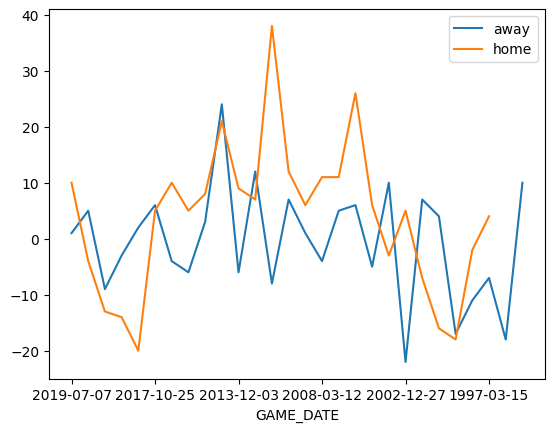

In [45]:
fig, ax = plt.subplots()

games_away.plot(x='GAME_DATE',y='PLUS_MINUS', ax=ax)
games_home.plot(x='GAME_DATE',y='PLUS_MINUS', ax=ax)
ax.legend(["away", "home"])
plt.show()

## Quiz


Calculate the mean for the column <code>PTS</code> for the dataframes <code>games_home</code> and <code> games_away</code>:


In [ ]:
# Write your code below and press Shift+Enter to execute


<details><summary>Click here for the solution</summary>

```python
games_home['PTS'].mean()

games_away['PTS'].mean()

```

</details>


## Authors:

[Joseph Santarcangelo](https://www.linkedin.com/in/joseph-s-50398b136/)

Joseph Santarcangelo has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.
<!---
## Change Log

| Date (YYYY-MM-DD) | Version | Changed By    | Change Description                 |
| ----------------- | ------- | ------------- | ---------------------------------- |
| 2023-11-09 | 2.2 | Abhishek Gagneja | Minor formatting updates and some instructional updates | 
| 2020-09-09        | 2.1     | Malika Singla | Spell Check                        |
| 2020-08-26        | 2.0     | Lavanya       | Moved lab to course repo in GitLab |
|                   |         |               |                                    |
|                   |         |               |                                    |
---!>

<hr/>

## <h3 align="center"> © IBM Corporation 2023. All rights reserved. <h3/>
